In [145]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

### File Reading

In [146]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

8


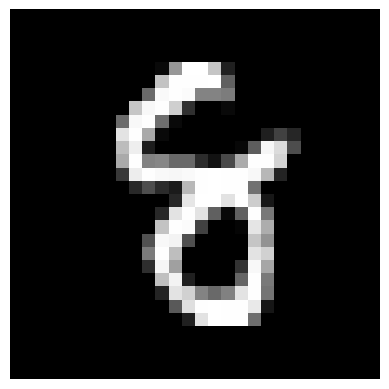

In [147]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [148]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1


train_set = np.array(train_set)
test_set = np.array(test_set)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
# normalizing the datasets
train_set = train_set.astype(np.float32)/255.0
test_set = test_set.astype(np.float32)/255.0

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


6


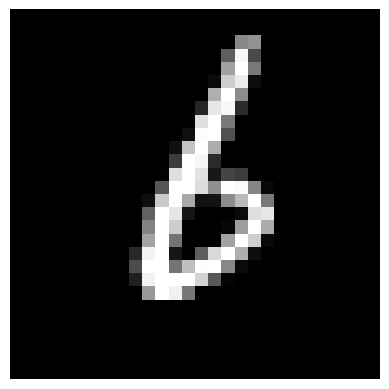

In [149]:
index = random.randint(0, 3999)

example_number = train_set[index]
example_label = train_labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [150]:
m, n = train_set.shape

X_train, X_test = train_set.T, test_set.T
Y_train, Y_test = train_labels.T, test_labels.T

_, m_train = X_train.shape
_, m_test = X_test.shape

In [151]:
# Shuffle training set
perm_train = np.random.permutation(X_train.shape[1])  # columns = samples
X_train = X_train[:, perm_train]
Y_train = np.array(Y_train)[perm_train]  

# Shuffle test set
perm_test = np.random.permutation(X_test.shape[1])
X_test = X_test[:, perm_test]
Y_test = np.array(Y_test)[perm_test]

### Implementing the Neural Network

In [152]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

# Rectified Linear Unit
def ReLU(x):
    return x * (x > 0)

def deriv_ReLU(Y):
    return Y > 0

# Softmax activation function
def softmax(x):
    sum_exp = sum(np.exp(x))
    softmax = np.exp(x) / sum_exp
    return softmax

# Tanh function
def tanh(x):
    return (2 / (1 + np.exp(-2 * np.clip(x, -100, 100)))) - 1

# Derivative of Tanh function
def deriv_tanh(Y):
    return 1 - np.clip(Y, -100, 100)**2

# Encodes scores into 0s or 1s
def encode_answers(x):
    enc = np.zeros((x.size, x.max() + 1))
    enc[np.arange(x.size), x] = 1
    enc = enc.T
    return enc

def forward(W1, b1, W2, b2, x):
    Z1 = W1.dot(x) + b1       # Hidden layer linear transformation
    A1 = ReLU(Z1)             # Hidden layer activation with tanh
    Z2 = W2.dot(A1) + b2      # Output layer linear transformation
    A2 = softmax(Z2)          # Output layer activation with softmax
    return Z1, A1, Z2, A2

def backward(Z1, A1, A2, W2, x, Y):
    encoding = encode_answers(Y)
    m = Y.size                                # Number of training examples
    
    # Output layer gradients
    dZ2 = A2 - encoding                       # Prediction - Real answer
    dW2 = 1 / m * dZ2.dot(A1.T)               # Gradient for W2
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)  # Gradient for b2

    # Hidden layer gradients
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)      # Backprop through tanh in hidden layer
    dW1 = 1 / m * dZ1.dot(x.T)                # Gradient for W1
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)  # Gradient for b1

    return dW1, db1, dW2, db2

# Updating weights and biases for a 2-layer neural network
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2
    return W1, b1, W2, b2

In [153]:
def calculate_confidence(Pred, Expect):
    return (np.sum(np.argmax(Pred, 0) == Expect)/Expect.size)

def gradient_descent(X, Y, epochs, lr = 0.01):
    W1, b1, W2, b2 = init_params()
    for i in range(epochs):
        Z1, A1, Z2, A2 = forward(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward(Z1, A1, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)
        if i % 10 == 0:
            print(f"Epoch: {i + 1}")
            print(f"Confidence: {calculate_confidence(A2, Y)}")

    return W1, b1, W2, b2

In [154]:
W1, b1, W2, b2= gradient_descent(X_train, Y_train, 160000, 0.1)

Epoch: 1
Confidence: 0.1


Epoch: 11
Confidence: 0.1
Epoch: 21
Confidence: 0.1
Epoch: 31
Confidence: 0.1
Epoch: 41
Confidence: 0.1
Epoch: 51
Confidence: 0.1
Epoch: 61
Confidence: 0.1
Epoch: 71
Confidence: 0.09975
Epoch: 81
Confidence: 0.099
Epoch: 91
Confidence: 0.0985
Epoch: 101
Confidence: 0.09875
Epoch: 111
Confidence: 0.09825
Epoch: 121
Confidence: 0.1
Epoch: 131
Confidence: 0.099
Epoch: 141
Confidence: 0.098
Epoch: 151
Confidence: 0.1015
Epoch: 161
Confidence: 0.102
Epoch: 171
Confidence: 0.10225
Epoch: 181
Confidence: 0.1005
Epoch: 191
Confidence: 0.0985
Epoch: 201
Confidence: 0.0895
Epoch: 211
Confidence: 0.08375
Epoch: 221
Confidence: 0.072
Epoch: 231
Confidence: 0.05775
Epoch: 241
Confidence: 0.05075
Epoch: 251
Confidence: 0.045
Epoch: 261
Confidence: 0.0485
Epoch: 271
Confidence: 0.0635
Epoch: 281
Confidence: 0.0785
Epoch: 291
Confidence: 0.088
Epoch: 301
Confidence: 0.09475
Epoch: 311
Confidence: 0.09625
Epoch: 321
Confidence: 0.0965
Epoch: 331
Confidence: 0.0965
Epoch: 341
Confidence: 0.096
Epoch: 35

In [155]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward(W1, b1, W2, b2, X)    # A2 is our output layer
    predictions = np.argmax(A2, 0)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_test[:, index, None]     # Printing out the images
    prediction = make_predictions(X_test[:, index, None], W1, b1, W2, b2)
    label = Y_test[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)).T * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [7]
Label:  7


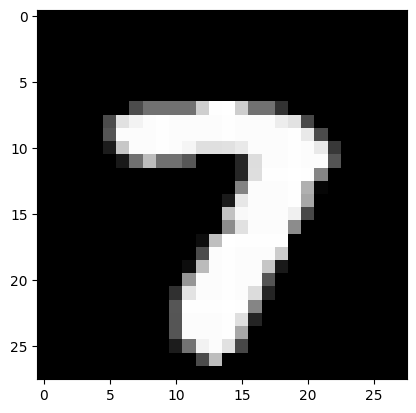

Prediction:  [2]
Label:  2


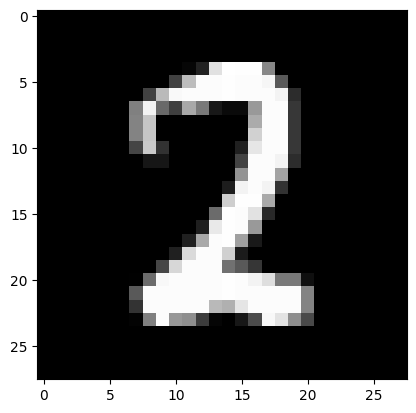

Prediction:  [8]
Label:  8


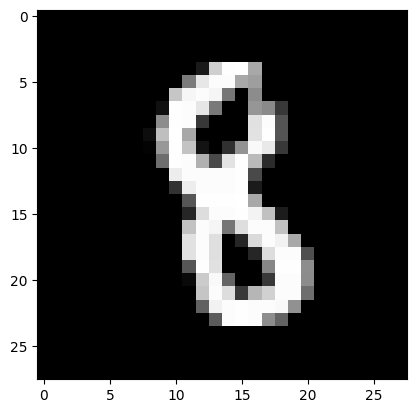

Prediction:  [2]
Label:  2


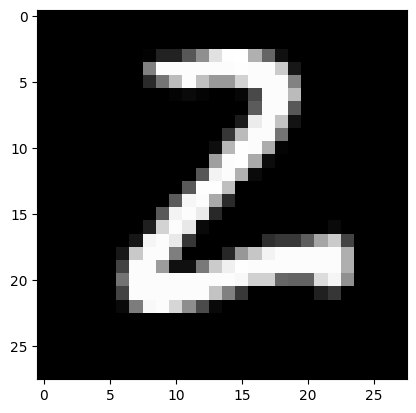

Prediction:  [6]
Label:  6


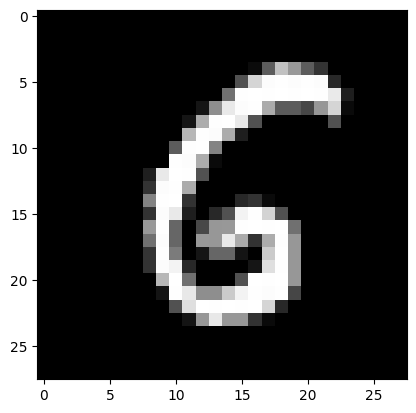

In [156]:
for _ in range(5):
    rand = random.randint(0, m_test - 1)
    test_prediction(rand, W1, b1, W2, b2)

In [157]:
# Calculate overall model accuracy
total = m_test  
corrects = 0    

# Iterate over each test example
for i in range(total):
    prediction = make_predictions(X_test[:, i, None], W1, b1, W2, b2)
    
    if prediction == Y_test[i]:  
        corrects += 1  

# Print overall accuracy
print(f"Overall accuracy: {corrects / total:.4f}")  


Overall accuracy: 0.8080


In [158]:
np.savez("model_weights.npz", W1=W1, b1=b1, W2=W2, b2=b2)

In [159]:
data = np.load("model_weights.npz")
W1_copy = data["W1"]
b1_copy = data["b1"]
W2_copy = data["W2"]
b2_copy = data["b2"]

In [161]:
W1 == W1_copy

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])